# G5-NB1 · 2D Ölçüm, Kalibrasyon ve Homography

**Amaç:** Pikselden milimetreye dönüşüm mantığını, kalibrasyon kavramını, referans nesne kullanımını ve homography ile perspektif düzeltmeyi uygulamalı öğrenmek.

**Bu notebook'ta öğrenecekleriniz:**
- Piksel neden gerçek ölçü değildir
- ArUco marker ile px → mm dönüşümü nasıl yapılır
- Homography (perspektif düzeltme) ne zaman kullanılır
- `minAreaRect` ile açılı nesnelerin boyutu nasıl ölçülür
- Chessboard kalibrasyon mantığı

**Ders sırasında kullanım:** Eğitmen slayt 26'dan sonra bu notebook'a geçecek, hücreleri sırayla çalıştıracaktır.

---


## [H1] Kurulum ve Kütüphaneler
Gerekli kütüphaneleri yüklüyoruz. OpenCV görüntü işleme, NumPy matris işlemleri, Matplotlib görselleştirme için kullanılır.


In [1]:
# ============================================
# [H1] KURULUM
# ============================================
# cv2      : OpenCV – goruntu isleme kutuphanesi
# numpy    : Matris/dizi islemleri (goruntu = numpy dizisi)
# matplotlib: Grafik ve goruntu gosterme

import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import patches

# Goruntu boyutunu ayarla
plt.rcParams['figure.figsize'] = (10, 6)

# --- Yardimci Fonksiyonlar ---

def show(img, title='', cmap=None):
    """Goruntuleri ekranda gosteren yardimci fonksiyon.
    BGR formatindaki goruntuleri otomatik olarak RGB'ye cevirir."""
    if img.ndim == 2:
        plt.imshow(img, cmap='gray')
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(title, fontsize=14, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.show()

def show_side(img1, img2, t1='', t2=''):
    """Iki goruntuyu yan yana gosterir – karsilastirma icin."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    ax1.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB) if img1.ndim==3 else img1, cmap='gray' if img1.ndim==2 else None)
    ax1.set_title(t1, fontsize=13); ax1.axis('off')
    ax2.imshow(cv2.cvtColor(img2, cv2.COLOR_BGR2RGB) if img2.ndim==3 else img2, cmap='gray' if img2.ndim==2 else None)
    ax2.set_title(t2, fontsize=13); ax2.axis('off')
    plt.tight_layout(); plt.show()

def order_points(pts):
    """4 kose noktasini saat yonunde siralar: sol-ust, sag-ust, sag-alt, sol-alt.
    Homography icin noktalarin tutarli sirada olmasi gerekir."""
    rect = np.zeros((4, 2), dtype='float32')
    s = pts.sum(axis=1)
    rect[0] = pts[np.argmin(s)]   # sol-ust (x+y en kucuk)
    rect[2] = pts[np.argmax(s)]   # sag-alt (x+y en buyuk)
    diff = np.diff(pts, axis=1)
    rect[1] = pts[np.argmin(diff)] # sag-ust
    rect[3] = pts[np.argmax(diff)] # sol-alt
    return rect

print("✓ Kurulum tamamlandi.")


✓ Kurulum tamamlandi.


## [H2] Piksel Nedir? – Temel Kavram

> **Piksel (Pixel):** Dijital görüntünün en küçük birimidir. Her piksel bir renk değeri taşır.
> Ama piksel, gerçek dünyadaki bir uzunluğu (mm, cm) doğrudan temsil etmez.
> Aynı nesne, farklı mesafeden çekildiğinde farklı piksel sayısı kaplar.
>
> **Bu yüzden:** Pikselden gerçek ölçüye geçmek için bir **referans nesne** gerekir.

Aşağıda aynı boyuttaki bir dikdörtgenin farklı "mesafelerden" (simülasyon) nasıl farklı piksel alanı kapladığını görüyoruz.


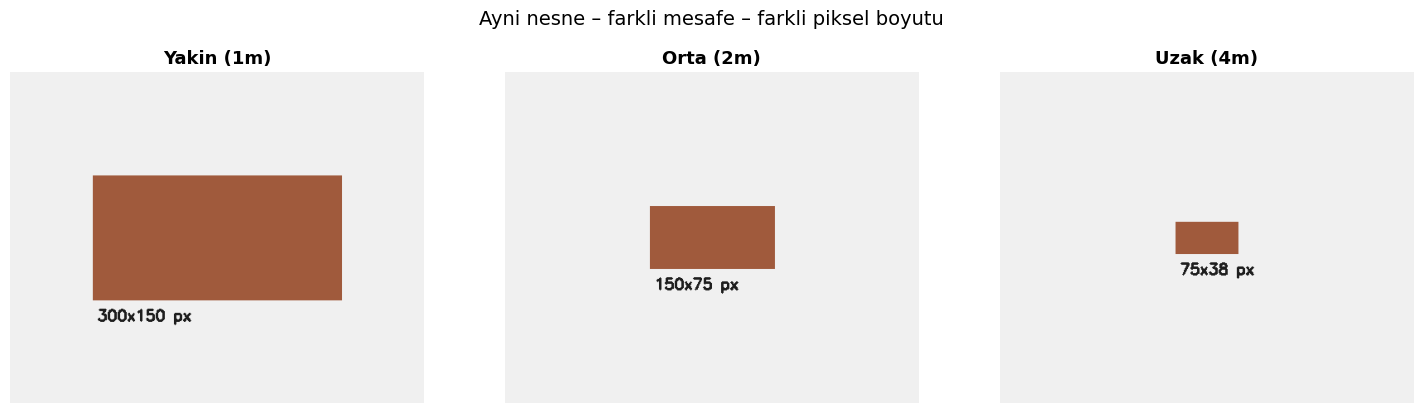

Sonuc: Piksel sayisi tek basina gercek boyutu soylemez.
Formul: mm_per_px = bilinen_gercek_olcu / piksel_karsiligi


In [2]:
# ============================================
# [H2] PIKSEL ≠ GERCEK OLCU – Gosterim
# ============================================
# Ayni "gercek boyuttaki" dikdortgen, farkli kamera mesafelerinde
# farkli piksel alani kaplar.

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Simulasyon: ayni nesne 3 farkli "mesafede"
distances = [("Yakin (1m)", 300, 150),
             ("Orta (2m)",  150, 75),
             ("Uzak (4m)",  75,  38)]

for ax, (label, w, h) in zip(axes, distances):
    canvas = np.full((400, 500, 3), 240, dtype=np.uint8)
    x0 = (500 - w) // 2
    y0 = (400 - h) // 2
    cv2.rectangle(canvas, (x0, y0), (x0+w, y0+h), (60, 90, 160), -1)
    cv2.putText(canvas, f"{w}x{h} px", (x0+5, y0+h+25),
                cv2.FONT_HERSHEY_SIMPLEX, 0.6, (30,30,30), 2)
    ax.imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
    ax.set_title(label, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle("Ayni nesne – farkli mesafe – farkli piksel boyutu", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("Sonuc: Piksel sayisi tek basina gercek boyutu soylemez.")
print("Formul: mm_per_px = bilinen_gercek_olcu / piksel_karsiligi")


## [H3] Sentetik Ölçüm Sahnesi Oluşturma

Gerçek boyutlarını bildiğimiz sentetik bir sahne oluşturuyoruz:
- **ArUco Marker** (80 mm kenar): Referans nesnemiz – piksel→mm oranını bundan çıkaracağız
- **Dikdörtgen nesne** (420×220 px, 6° dönmüş): Ölçeceğimiz "sac levha" benzeri obje
- **Dekoratif coil izi**: Sahneyi gerçekçi kılmak için

> **ArUco Marker:** OpenCV kütüphanesindeki özel kare kodlardır. Her birinin benzersiz bir ID'si vardır.
> Otomatik tespit edilir, köşe noktaları piksel hassasiyetinde bulunur.


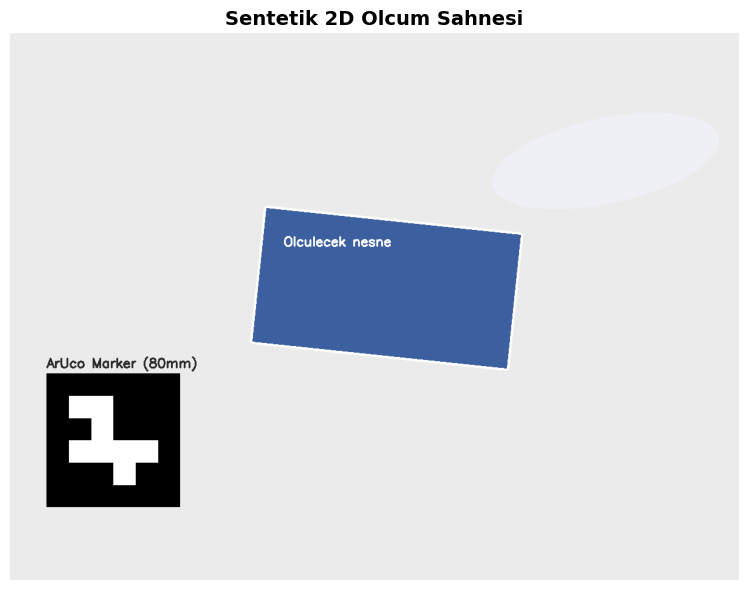

Sahne boyutu: 1200x900 piksel
ArUco marker gercek kenar uzunlugu: 80.0 mm
Dikdortgen: 420x220 px, 6° donmus


In [3]:
# ============================================
# [H3] SENTETIK OLCUM SAHNESI
# ============================================
# Neden sentetik? Gercek boyutlari bildigimiz bir sahne
# uzerinde calisarak dogrulama yapabiliyoruz.

H, W = 900, 1200
scene = np.full((H, W, 3), 235, dtype=np.uint8)  # Acik gri zemin

# --- ArUco Marker (referans nesne) ---
# ArUco: OpenCV'nin otomatik tanimlayabildigi ozel kare kodlar.
# DICT_4X4_50 = 4x4 bitlik, 50 farkli marker iceren sozluk.
aruco_dict = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)
marker = cv2.aruco.generateImageMarker(aruco_dict, 7, 220)  # ID=7, 220x220 px
marker_bgr = cv2.cvtColor(marker, cv2.COLOR_GRAY2BGR)
scene[560:780, 60:280] = marker_bgr  # Sol alta yerlestir

# --- Olculecek dikdortgen nesne (sac levha benzeri) ---
rect_center = (620, 420)    # Merkez koordinati (piksel)
rect_size   = (420, 220)    # Genislik x Yukseklik (piksel)
rect_angle  = 6             # 6 derece donmus
box = cv2.boxPoints((rect_center, rect_size, rect_angle)).astype(np.int32)
cv2.drawContours(scene, [box], 0, (255, 255, 255), 8)
cv2.fillPoly(scene, [box], (160, 95, 60))  # Kahverengi dolgu

# --- Dekoratif coil izi ---
cv2.ellipse(scene, (980, 210), (190, 70), -12, 0, 360, (245, 240, 238), -1)

# Etiketler
cv2.putText(scene, "ArUco Marker (80mm)", (60, 550),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (40,40,40), 2)
cv2.putText(scene, "Olculecek nesne", (450, 350),
            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,255), 2)

show(scene, "Sentetik 2D Olcum Sahnesi")
print(f"Sahne boyutu: {W}x{H} piksel")
print(f"ArUco marker gercek kenar uzunlugu: 80.0 mm")
print(f"Dikdortgen: {rect_size[0]}x{rect_size[1]} px, {rect_angle}° donmus")


## [H4] ArUco Tespiti ve Piksel → Milimetre Dönüşümü

> **px → mm Dönüşümü:** Bilinen gerçek uzunluğu olan bir nesnenin piksel karşılığını ölçerek
> her pikselin kaç milimetreye denk geldiğini hesaplıyoruz.
>
> `mm_per_px = gerçek_uzunluk_mm / piksel_uzunluk`
>
> **Kritik kural:** Referans nesne ile ölçülecek obje **aynı düzlemde** olmalı!


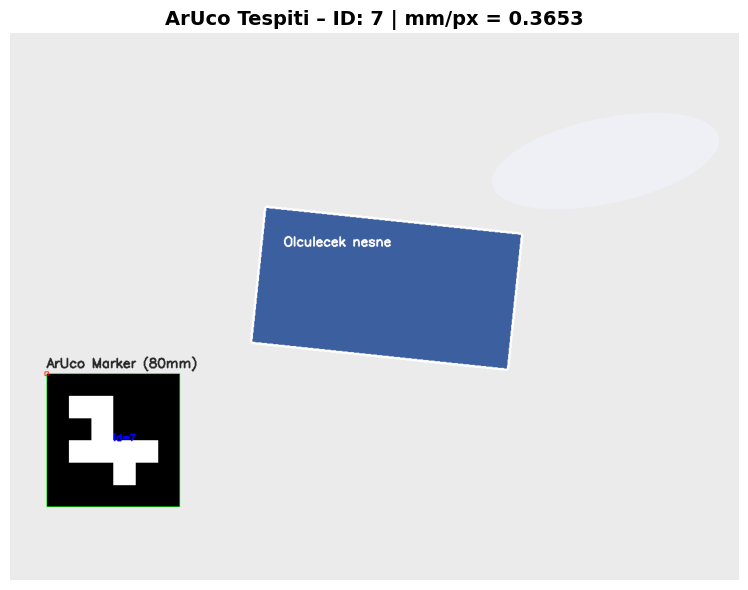

Marker ID          : 7
Marker cevresi     : 876.0 px
Marker kenar (px)  : 219.0 px
Marker kenar (mm)  : 80.0 mm
─────────────────────────────
mm / piksel        : 0.3653
Yani 1 piksel      ≈ 0.365 mm
Yani 100 piksel    ≈ 36.5 mm


In [4]:
# ============================================
# [H4] ARUCO TESPITI ve PX -> MM DONUSUMU
# ============================================
# Adim 1: ArUco marker'i otomatik tespit et
# Adim 2: Marker kenar uzunlugunu piksel cinsinden olc
# Adim 3: Gercek boyut / piksel boyut = mm_per_px

detector = cv2.aruco.ArucoDetector(aruco_dict)
corners, ids, rejected = detector.detectMarkers(scene)

# Gorsellestirme
vis = scene.copy()
cv2.aruco.drawDetectedMarkers(vis, corners, ids)

# Referans marker'in gercek boyutu (basilmis sablon: 80 mm)
MARKER_REAL_MM = 80.0

# Marker koselerinden kenar uzunlugunu hesapla
c = corners[0].reshape(-1, 2)          # 4 kose noktasi
perimeter = cv2.arcLength(c.astype(np.float32), True)  # Cevre uzunlugu
side_px = perimeter / 4.0              # Bir kenar = cevre / 4

# TEMEL DONUSUM
mm_per_px = MARKER_REAL_MM / side_px

show(vis, f"ArUco Tespiti – ID: {ids[0][0]} | mm/px = {mm_per_px:.4f}")

print(f"Marker ID          : {ids[0][0]}")
print(f"Marker cevresi     : {perimeter:.1f} px")
print(f"Marker kenar (px)  : {side_px:.1f} px")
print(f"Marker kenar (mm)  : {MARKER_REAL_MM} mm")
print(f"─────────────────────────────")
print(f"mm / piksel        : {mm_per_px:.4f}")
print(f"Yani 1 piksel      ≈ {mm_per_px:.3f} mm")
print(f"Yani 100 piksel    ≈ {100*mm_per_px:.1f} mm")


## [H5] Homography ile Perspektif Düzeltme

> **Homography:** Düzlemsel bir yüzeyi farklı bir bakış açısına taşıyan geometrik dönüşümdür.
> Eğik çekilmiş bir düzlemsel sahneyi, sanki tam üstten bakıyormuş gibi düzeltir.
>
> `cv2.getPerspectiveTransform(kaynak_4_nokta, hedef_4_nokta)` → 3×3 dönüşüm matrisi
> `cv2.warpPerspective(görüntü, matris, boyut)` → düzeltilmiş görüntü
>
> **Ne zaman kullanılır?** Kamera biraz eğik ama sahne düzlemsel ise.
> **Ne zaman yetmez?** Yükseklik değişiyorsa (3D problem).


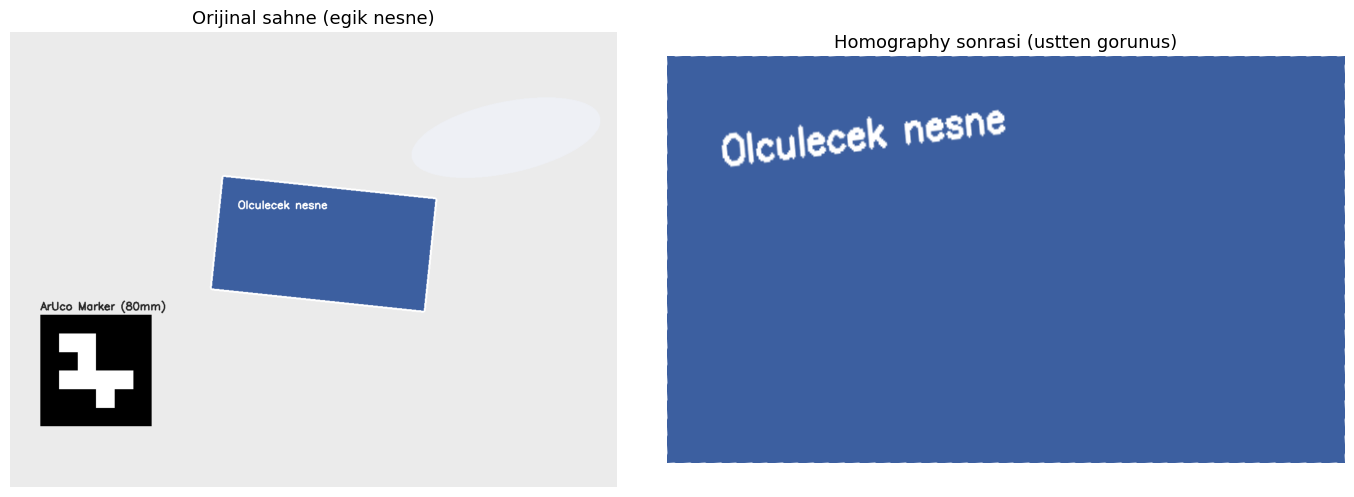

Homography matrisi (3x3):
[[ 1.6500e+00  1.7000e-01 -7.4800e+02]
 [-2.0000e-01  1.8900e+00 -4.6093e+02]
 [ 0.0000e+00  0.0000e+00  1.0000e+00]]

Duzeltilmis goruntu boyutu: 700x420 px


In [5]:
# ============================================
# [H5] HOMOGRAPHY – PERSPEKTIF DUZELTME
# ============================================
# Dikdortgenin 4 kose noktasini alip, duz bir dikdortgene map'liyoruz.
# Bu "sanki tam ustten bakiyormus gibi" goruntuyu verir.

# Kaynak: dikdortgenin gercek koseleri (egik)
src_pts = order_points(box.astype(np.float32))

# Hedef: duz bir dikdortgen
target_w, target_h = 700, 420
dst_pts = np.array([
    [0, 0],
    [target_w - 1, 0],
    [target_w - 1, target_h - 1],
    [0, target_h - 1]
], dtype='float32')

# Homography matrisi hesapla (3x3)
H_matrix = cv2.getPerspectiveTransform(src_pts, dst_pts)

# Uygula: egik goruntuyu duzlestir
warped = cv2.warpPerspective(scene, H_matrix, (target_w, target_h))

# Karsilastirma
show_side(scene, warped,
          "Orijinal sahne (egik nesne)",
          "Homography sonrasi (ustten gorunus)")

print("Homography matrisi (3x3):")
print(np.round(H_matrix, 2))
print(f"\nDuzeltilmis goruntu boyutu: {target_w}x{target_h} px")


## [H6] minAreaRect ile Boyut Ölçümü

> **minAreaRect:** Bir konturu saran minimum alanlı döndürülmüş dikdörtgeni bulur.
> Axis-aligned `boundingRect`'ten farklı olarak, nesne eğik olsa bile doğru boyutu verir.
>
> **Axis-aligned kutu:** Nesne 30° dönmüşse, kutu gerçekten büyük çıkar (fazla alan sarar).
> **Rotated kutu (minAreaRect):** Nesneye tam oturur, gerçek boyutu verir.


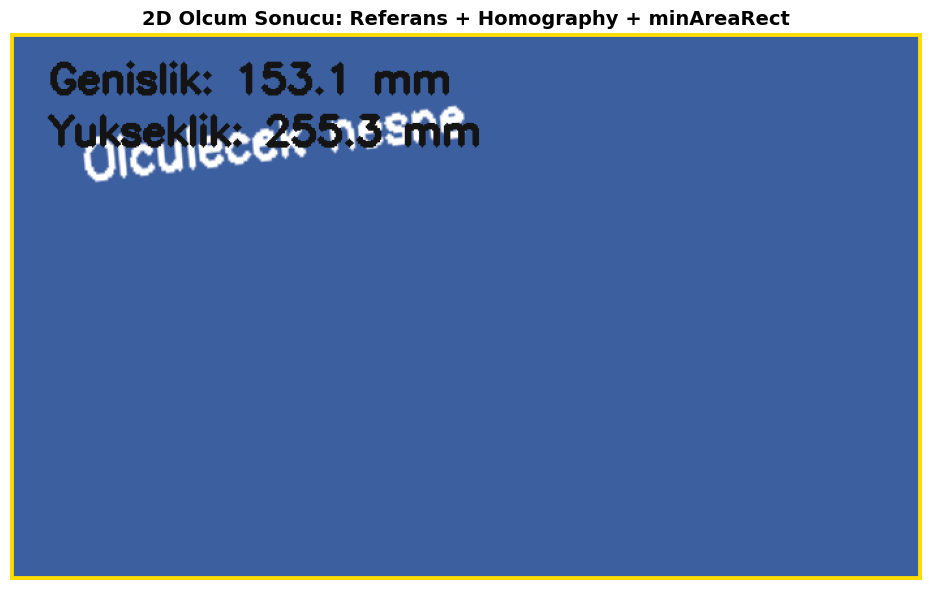

         2D OLCUM SONUCLARI
Genislik  : 419 px  →  153.1 mm
Yukseklik : 699 px  →  255.3 mm
Aci       : -90.0°
mm/px     : 0.3653

Pipeline ozeti:
  1. Sahneyi al
  2. ArUco marker ile mm/px oranini bul
  3. Homography ile perspektifi duzelt
  4. Kontur bul → minAreaRect
  5. Piksel x mm/px = gercek olcu


In [6]:
# ============================================
# [H6] minAreaRect ile BOYUT OLCUMU
# ============================================
# Adim 1: Duzeltilmis goruntude nesneyi bul (threshold + kontur)
# Adim 2: minAreaRect ile en kucuk sarilmis dikdortgeni cikar
# Adim 3: Piksel boyutunu mm'ye cevir

# Gri tonlamaya cevir ve threshold uygula
gray = cv2.cvtColor(warped, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 180, 255, cv2.THRESH_BINARY_INV)

# Konturlari bul
contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
cnt = max(contours, key=cv2.contourArea)  # En buyuk kontur = nesnemiz

# minAreaRect: minimum alanli dondurulmus dikdortgen
rect = cv2.minAreaRect(cnt)
(cx, cy), (rect_w, rect_h), angle = rect
box2 = cv2.boxPoints(rect).astype(int)

# Sonuc goruntusu
result = warped.copy()
cv2.drawContours(result, [box2], 0, (0, 220, 255), 4)

# Piksel -> mm donusumu
width_mm  = rect_w * mm_per_px
height_mm = rect_h * mm_per_px

# Etiketler
cv2.putText(result, f"Genislik: {width_mm:.1f} mm", (30, 45),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 3)
cv2.putText(result, f"Yukseklik: {height_mm:.1f} mm", (30, 85),
            cv2.FONT_HERSHEY_SIMPLEX, 1.0, (20, 20, 20), 3)

show(result, "2D Olcum Sonucu: Referans + Homography + minAreaRect")

print("="*50)
print("         2D OLCUM SONUCLARI")
print("="*50)
print(f"Genislik  : {rect_w:.0f} px  →  {width_mm:.1f} mm")
print(f"Yukseklik : {rect_h:.0f} px  →  {height_mm:.1f} mm")
print(f"Aci       : {angle:.1f}°")
print(f"mm/px     : {mm_per_px:.4f}")
print("="*50)
print()
print("Pipeline ozeti:")
print("  1. Sahneyi al")
print("  2. ArUco marker ile mm/px oranini bul")
print("  3. Homography ile perspektifi duzelt")
print("  4. Kontur bul → minAreaRect")
print("  5. Piksel x mm/px = gercek olcu")


## [H7] Axis-Aligned vs Rotated Box Karşılaştırma

Bu farkı anlamak önemli: eğik bir nesneye axis-aligned kutu çizersek boyut şişer.


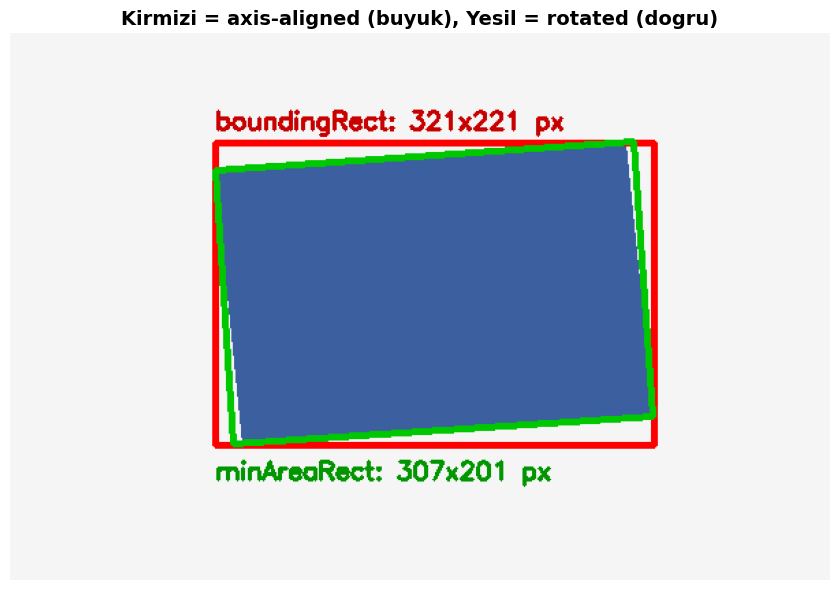

Axis-aligned alan : 70,941 px²
Rotated alan      : 61,736 px²
Fark              : %15 daha buyuk

Sonuc: Egik nesnelerde minAreaRect kullanmak daha dogru boyut verir.


In [7]:
# ============================================
# [H7] AXIS-ALIGNED vs ROTATED BOX FARKI
# ============================================
# Nesneler her zaman duz durmuyor. Egik bir nesneye
# duz dikdortgen cizerseniz boyut buyuk cikar.

demo = np.full((400, 600, 3), 245, dtype=np.uint8)

# Egik dikdortgen
pts = np.array([[150,100],[450,80],[470,280],[170,300]], dtype=np.int32)
cv2.fillPoly(demo, [pts], (160,95,60))

# Axis-aligned (duz) bounding box – KIRMIZI
x,y,w,h = cv2.boundingRect(pts)
cv2.rectangle(demo, (x,y), (x+w,y+h), (0,0,255), 3)
cv2.putText(demo, f"boundingRect: {w}x{h} px", (x, y-10),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,200), 2)

# Rotated (dondurulmus) bounding box – YESIL
rr = cv2.minAreaRect(pts)
box_r = cv2.boxPoints(rr).astype(int)
cv2.drawContours(demo, [box_r], 0, (0,200,0), 3)
(_,_), (rw,rh), _ = rr
cv2.putText(demo, f"minAreaRect: {rw:.0f}x{rh:.0f} px", (x, y+h+25),
            cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,150,0), 2)

show(demo, "Kirmizi = axis-aligned (buyuk), Yesil = rotated (dogru)")
print(f"Axis-aligned alan : {w*h:,} px²")
print(f"Rotated alan      : {rw*rh:,.0f} px²")
print(f"Fark              : %{((w*h)/(rw*rh)-1)*100:.0f} daha buyuk")
print("\nSonuc: Egik nesnelerde minAreaRect kullanmak daha dogru boyut verir.")


## [H8] Chessboard Kalibrasyon Mantığı (Kavramsal)

> **Kamera Kalibrasyonu:** Kameranın iç parametrelerini (focal length, principal point, lens bozulması)
> öğrenme işlemidir. Chessboard deseni kullanarak yapılır.
>
> **Çıktılar:**
> - **K matrisi (intrinsic):** Odak uzaklığı ve optik merkez
> - **Distortion katsayıları:** Radial ve tangential lens bozulması
> - **Extrinsic:** Kameranın sahneye göre konumu (multi-camera için)

Bu hücre kavramsal bir gösterimdir. Gerçek chessboard kalibrasyonu için fiziksel bir baskı ve kamera gerekir.


In [8]:
# ============================================
# [H8] CHESSBOARD KALIBRASYON – KAVRAMSAL
# ============================================
# Gercek kalibrasyon icin fiziksel chessboard baskilari gerekir.
# Burada sadece mantigi ve OpenCV fonksiyonlarini gosteriyoruz.

# Ornek kalibrasyon kodu (calistirilmaz, referans icin):
kalibrasyon_kodu = '''
# 1. Chessboard deseni parametreleri
PATTERN = (9, 6)       # 9x6 ic kose noktasi
SQUARE_SIZE = 20.0     # Her kare 20 mm

# 2. 3D dunya noktalarini hazirla
objp = np.zeros((PATTERN[0]*PATTERN[1], 3), np.float32)
objp[:,:2] = np.mgrid[0:PATTERN[0], 0:PATTERN[1]].T.reshape(-1, 2)
objp *= SQUARE_SIZE

# 3. Her goruntude kose noktalarini bul
ret, corners = cv2.findChessboardCorners(gray, PATTERN, None)

# 4. Kalibrasyonu hesapla
ret, K, dist, rvecs, tvecs = cv2.calibrateCamera(
    obj_points, img_points, gray.shape[::-1], None, None
)

# 5. Bozulmayi duzelt
undistorted = cv2.undistort(image, K, dist)
'''

print("KALIBRASYON ADIM ADIM")
print("="*50)
print("1. Chessboard baskilarini farkli aci/konumda cek")
print("2. findChessboardCorners ile koseleri bul")
print("3. calibrateCamera ile K, dist, rvecs, tvecs hesapla")
print("4. undistort ile lens bozulmasini duzelt")
print("="*50)
print()
print("K matrisi ornegi:")
print("  [[fx,  0, cx],")
print("   [ 0, fy, cy],")
print("   [ 0,  0,  1]]")
print()
print("fx, fy = focal length (piksel)")
print("cx, cy = principal point (optik merkez)")
print()
print("Distortion katsayilari: [k1, k2, p1, p2, k3]")
print("  k1,k2,k3 = radial (kenarlarda egrilme)")
print("  p1,p2    = tangential (eksen kaymasi)")
print()
print("Not: Yazdirma sablonlari print_sablonlari/ klasorundedir:")
print("  - chessboard_A4_9x6_20mm.pdf")
print("  - aruco_A4_80mm.pdf")
print("  - ruler_A4_0_200mm.pdf")


KALIBRASYON ADIM ADIM
1. Chessboard baskilarini farkli aci/konumda cek
2. findChessboardCorners ile koseleri bul
3. calibrateCamera ile K, dist, rvecs, tvecs hesapla
4. undistort ile lens bozulmasini duzelt

K matrisi ornegi:
  [[fx,  0, cx],
   [ 0, fy, cy],
   [ 0,  0,  1]]

fx, fy = focal length (piksel)
cx, cy = principal point (optik merkez)

Distortion katsayilari: [k1, k2, p1, p2, k3]
  k1,k2,k3 = radial (kenarlarda egrilme)
  p1,p2    = tangential (eksen kaymasi)

Not: Yazdirma sablonlari print_sablonlari/ klasorundedir:
  - chessboard_A4_9x6_20mm.pdf
  - aruco_A4_80mm.pdf
  - ruler_A4_0_200mm.pdf


## [H9] Özet ve Temel Kavramlar

Bu notebook'ta öğrendiğimiz kavramların özeti.


In [9]:
# ============================================
# [H9] OZET
# ============================================
print('''
╔══════════════════════════════════════════════════════════╗
║              2D OLCUM – OZET                            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Piksel ≠ gercek olcu                                ║
║     → Referans nesne (ArUco/cetvel) gerekir             ║
║                                                          ║
║  2. mm/px = bilinen_mm / piksel_karsiligi               ║
║     → Referans ve olculen nesne AYNI DUZLEMDE olmali    ║
║                                                          ║
║  3. Homography = duzlemsel perspektif duzeltme           ║
║     → Egik cekimi ustten bakisa donusturur              ║
║     → Sadece duzlemsel problemlerde gecerli              ║
║                                                          ║
║  4. minAreaRect > boundingRect (egik nesnelerde)         ║
║     → Daha dogru boyut verir                            ║
║                                                          ║
║  5. Kalibrasyon = kameranin ic yapisini ogrenme          ║
║     → K matrisi + distortion + extrinsic                ║
║     → undistort → daha tutarli olcum                    ║
║                                                          ║
║  Pipeline: Goruntu → Referans → Homography →            ║
║            Kontur → px×mm/px → Gercek olcu              ║
║                                                          ║
╚══════════════════════════════════════════════════════════╝
''')



╔══════════════════════════════════════════════════════════╗
║              2D OLCUM – OZET                            ║
╠══════════════════════════════════════════════════════════╣
║                                                          ║
║  1. Piksel ≠ gercek olcu                                ║
║     → Referans nesne (ArUco/cetvel) gerekir             ║
║                                                          ║
║  2. mm/px = bilinen_mm / piksel_karsiligi               ║
║     → Referans ve olculen nesne AYNI DUZLEMDE olmali    ║
║                                                          ║
║  3. Homography = duzlemsel perspektif duzeltme           ║
║     → Egik cekimi ustten bakisa donusturur              ║
║     → Sadece duzlemsel problemlerde gecerli              ║
║                                                          ║
║  4. minAreaRect > boundingRect (egik nesnelerde)         ║
║     → Daha dogru boyut verir                            ║
║                             